In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
artists = pd.read_csv(
    "artists.dat", sep="\t", header=None, names=["artist_id", "name", "url", "picture_url"], encoding="latin1"
)

In [4]:
artists.head()

,artist_id,name,url,picture_url
0,id,name,url,pictureURL
1,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
2,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
3,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
4,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...


In [5]:
artists.shape

(17633, 4)

In [6]:
artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17633 entries, 0 to 17632
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   artist_id    17633 non-null  object
 1   name         17633 non-null  object
 2   url          17633 non-null  object
 3   picture_url  17189 non-null  object
dtypes: object(4)
memory usage: 551.2+ KB


In [7]:
artists.isnull().sum()

artist_id        0
name             0
url              0
picture_url    444
dtype: int64

In [8]:
tags = pd.read_csv(
    "tags.dat", sep="\t", header=None, names=["tags_id", "tag"], encoding="latin1"
)

In [9]:
tags.head()

,tags_id,tag
0,tagID,tagValue
1,1,metal
2,2,alternative metal
3,3,goth rock
4,4,black metal


In [10]:
tags.shape

(11947, 2)

In [11]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11947 entries, 0 to 11946
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tags_id  11947 non-null  object
 1   tag      11947 non-null  object
dtypes: object(2)
memory usage: 186.8+ KB


In [12]:
tags.isnull().sum()

tags_id    0
tag        0
dtype: int64

In [13]:
user_artists = pd.read_csv(
    "user_artists.dat", sep="\t", header=None, names=["user_id", "artist_id", "listen_count"], encoding="latin1"
)

In [14]:
user_artists.head()

,user_id,artist_id,listen_count
0,userID,artistID,weight
1,2,51,13883
2,2,52,11690
3,2,53,11351
4,2,54,10300


In [15]:
user_artists.shape

(92835, 3)

In [16]:
user_artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92835 entries, 0 to 92834
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       92835 non-null  object
 1   artist_id     92835 non-null  object
 2   listen_count  92835 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


In [17]:
user_artists.isnull().sum()

user_id         0
artist_id       0
listen_count    0
dtype: int64

In [18]:
user_artists["listen_count"] = pd.to_numeric(
    user_artists["listen_count"],
    errors="coerce"
)

In [19]:
user_artists.dtypes

user_id          object
artist_id        object
listen_count    float64
dtype: object

In [20]:
user_friends = pd.read_csv(
    "user_friends.dat", sep="\t", header=None, names=["user_id", "friend_id"], encoding="latin1"
)

In [21]:
user_friends.head()

,user_id,friend_id
0,userID,friendID
1,2,275
2,2,428
3,2,515
4,2,761


In [22]:
user_friends.shape

(25435, 2)

In [23]:
user_friends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25435 entries, 0 to 25434
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    25435 non-null  object
 1   friend_id  25435 non-null  object
dtypes: object(2)
memory usage: 397.5+ KB


In [24]:
user_friends.isnull().sum()

user_id      0
friend_id    0
dtype: int64

In [25]:
user_artists["user_id"].nunique()

1893

In [26]:
user_artists["artist_id"].nunique()

17633

In [27]:
top_artists = (
    user_artists.groupby("artist_id", as_index=False)["listen_count"]
    .sum()
    .sort_values(by="listen_count", ascending=False)
    .head(10)
)
top_artists

,artist_id,listen_count
9976,289,2393140.0
14629,72,1301308.0
16450,89,1291387.0
10009,292,1058405.0
12204,498,963449.0
14083,67,921198.0
9965,288,905423.0
14419,701,688529.0
9293,227,662116.0
10099,300,532545.0


In [28]:
top_artists.shape

(10, 2)

In [29]:
top_artists.head()

,artist_id,listen_count
9976,289,2393140.0
14629,72,1301308.0
16450,89,1291387.0
10009,292,1058405.0
12204,498,963449.0


In [30]:
top_artists = top_artists.merge(
    artists, on="artist_id", how="left"
)
top_artists[["name", "listen_count"]]

,name,listen_count
0,Britney Spears,2393140.0
1,Depeche Mode,1301308.0
2,Lady Gaga,1291387.0
3,Christina Aguilera,1058405.0
4,Paramore,963449.0
5,Madonna,921198.0
6,Rihanna,905423.0
7,Shakira,688529.0
8,The Beatles,662116.0
9,Katy Perry,532545.0


In [31]:
top_artists = top_artists.dropna(subset=["name"])

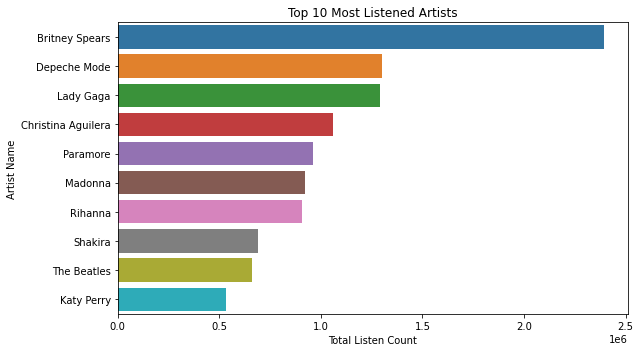

In [32]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_artists,
    x="listen_count",
    y="name"
)
plt.title("Top 10 Most Listened Artists")
plt.xlabel("Total Listen Count")
plt.ylabel("Artist Name")
plt.tight_layout()
plt.show()
